# Predicting EV Purchases

**Competition:** [Kaggle Playground Series S6E9 - Predicting Electric Vehicle Purchases](https://www.kaggle.com/competitions/playground-series-s6e9)

**Task:** binary classification: predict whether a person will buy an electric vehicle (`Will_Buy_EV`) from demographic, financial, and behavioral features. Official competition metric: **ROC-AUC**.


I tried answering this with a **2x2 ablation**: {Logistic Regression, LightGBM} x {raw features, hand-engineered features}. Then I have tired addding some more models to see if they can contribute any more performance.

## 1. importing libraries and setup

In [1]:
import os
import zipfile
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    classification_report, ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from lightgbm import LGBMClassifier

# sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

COMPETITION = "playground-series-s6e9"
DATA_DIR = "../data/raw"
RAW_DATA_PATH = os.path.join(DATA_DIR, "train.csv")

## 2. get the data

Downloaede the dataset directly from the kaggle competition page

### 2.1 loading data

In [2]:
df = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(df.shape)
df.head()

(668665, 14)


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
id,,,,,,,,,,,,,,
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668665 entries, 0 to 668664
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          668665 non-null  int64  
 1   Annual_Income_USD            668665 non-null  float64
 2   Daily_Commute_km             668665 non-null  float64
 3   Number_of_Cars_Owned         668665 non-null  int64  
 4   Charging_Stations_Near_Home  668665 non-null  int64  
 5   Charging_Stations_Near_Work  668665 non-null  int64  
 6   Environmental_Concern_Level  668665 non-null  float64
 7   Gender                       668665 non-null  object 
 8   City_Type                    668665 non-null  object 
 9   Current_Car_Type             668665 non-null  object 
 10  Home_Charging_Possible       668665 non-null  object 
 11  Subsidy_Available            668665 non-null  object 
 12  Range_Anxiety_Level          668665 non-null  object 
 13  Will

In [4]:
# confirm there's no missing data before we move on
df.isna().mean().sort_values(ascending=False) * 100

Age                            0.0
Annual_Income_USD              0.0
Daily_Commute_km               0.0
Number_of_Cars_Owned           0.0
Charging_Stations_Near_Home    0.0
Charging_Stations_Near_Work    0.0
Environmental_Concern_Level    0.0
Gender                         0.0
City_Type                      0.0
Current_Car_Type               0.0
Home_Charging_Possible         0.0
Subsidy_Available              0.0
Range_Anxiety_Level            0.0
Will_Buy_EV                    0.0
dtype: float64

## 3. Exploratory Data Analysis

### 3.1 Target balance

`Will_Buy_EV` is imbalanced (~17.5% "Yes"). Used the `class_weight="balanced"` / `scale_pos_weight` in the models rather than resampling.


Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


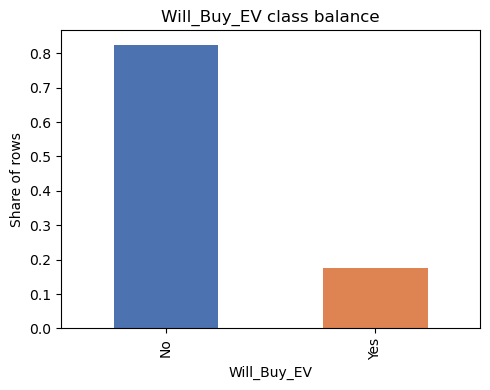

In [5]:
target_counts = df["Will_Buy_EV"].value_counts(normalize=True)
print(target_counts)

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Share of rows")
ax.set_title("Will_Buy_EV class balance")
plt.tight_layout()
plt.show()

### 3.2 Numeric feature distributions

In [6]:
numeric_cols = [
    "Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home", "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
]
df[numeric_cols].describe().round(1)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.0,668665.0,668665.0,668665.0,668665.0,668665.0,668665.0
mean,47.0,84769.3,32.2,1.7,5.0,7.2,2.9
std,12.9,28648.0,18.7,0.7,3.9,5.2,1.4
min,25.0,30000.0,5.0,1.0,0.0,0.0,1.0
25%,36.0,67376.0,17.2,1.0,2.0,3.0,2.0
50%,47.0,84880.0,33.6,2.0,4.0,6.0,3.0
75%,58.0,102753.0,47.4,2.0,7.0,10.0,4.0
max,69.0,188549.0,98.7,4.0,14.0,19.0,5.0


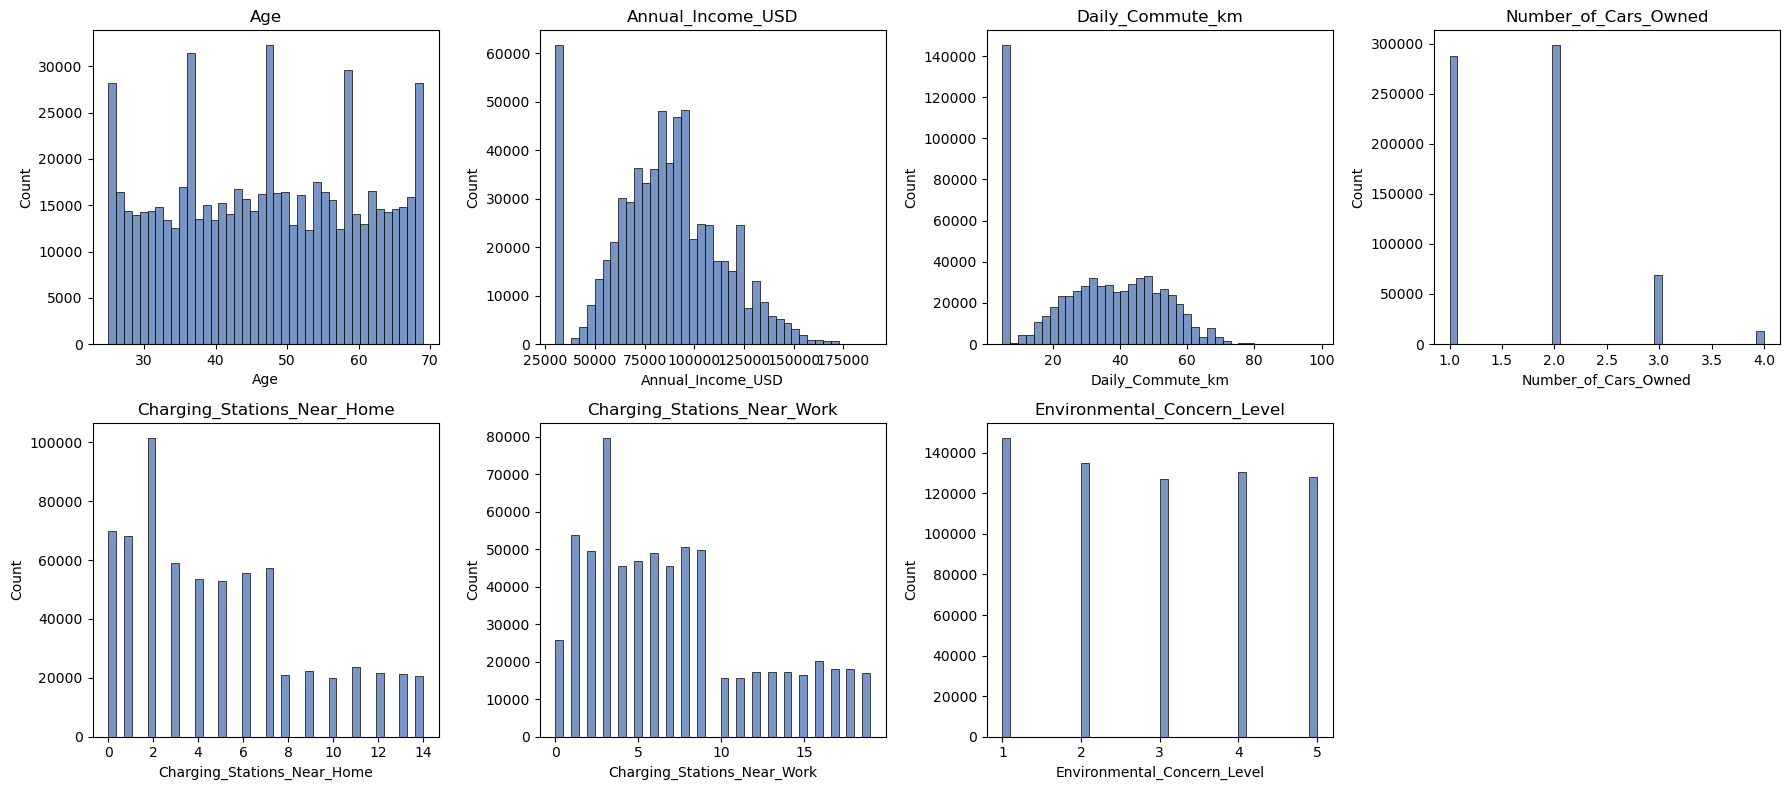

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

### 3.3 Categorical features

In [8]:
categorical_cols = [
    "Gender", "City_Type", "Current_Car_Type", "Home_Charging_Possible",
    "Subsidy_Available", "Range_Anxiety_Level",
]
for c in categorical_cols:
    print(c, "->", df[c].unique())


Gender -> ['Male' 'Female' 'Other']
City_Type -> ['Suburban' 'Rural' 'Urban']
Current_Car_Type -> ['Sedan' 'SUV' 'Hatchback' 'Truck']
Home_Charging_Possible -> ['Yes' 'No']
Subsidy_Available -> ['No' 'Yes']
Range_Anxiety_Level -> ['Low' 'Medium' 'High']


### 3.4 How each feature relates to the target

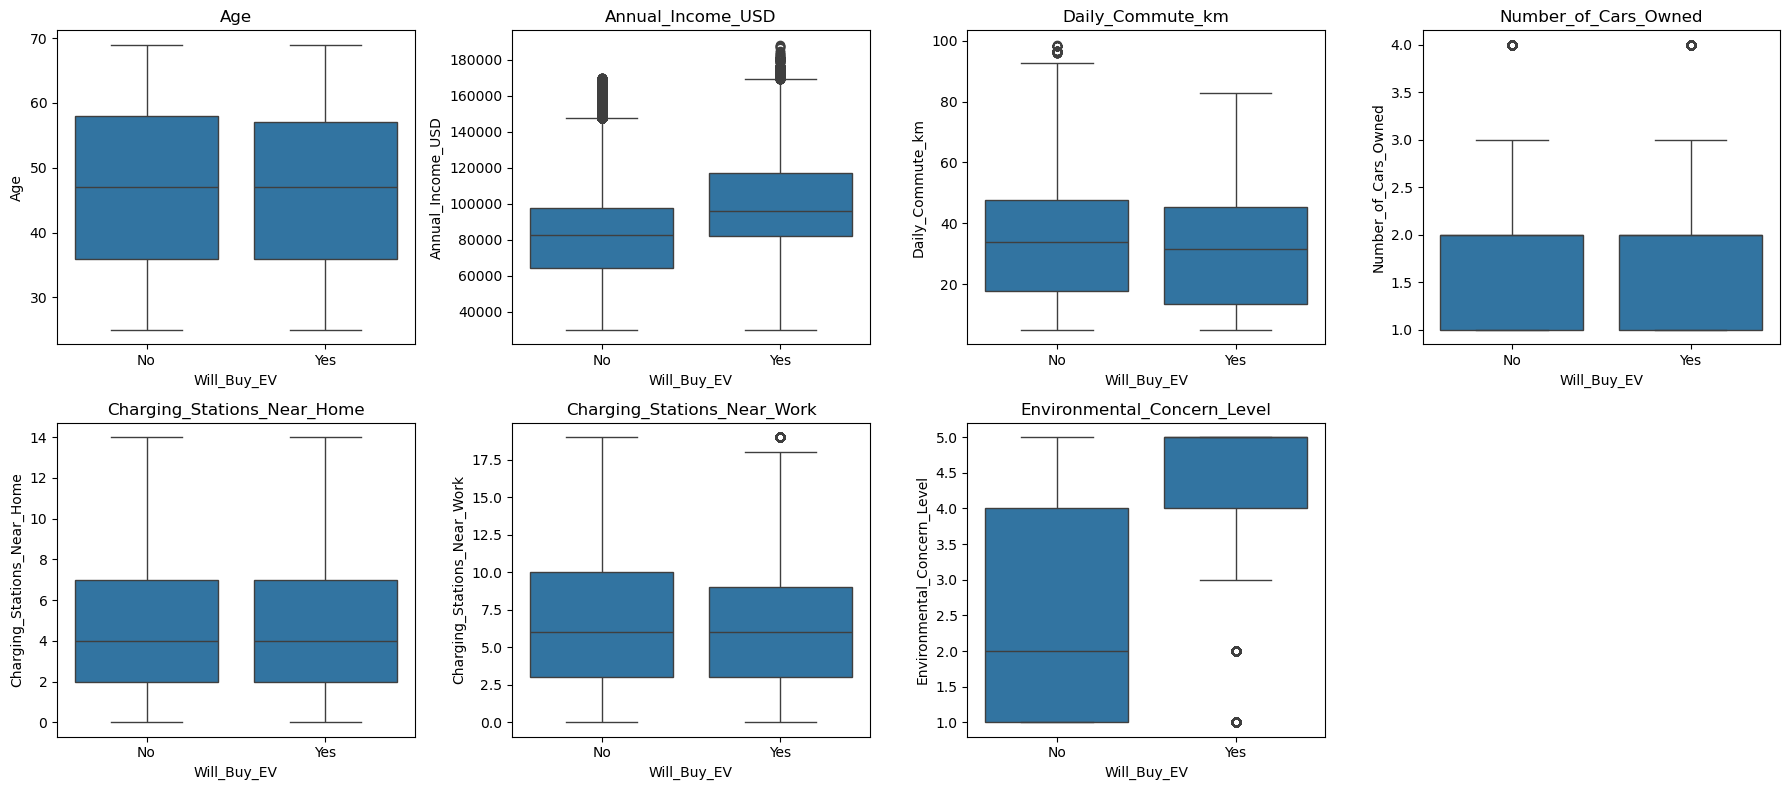

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=df, x="Will_Buy_EV", y=col, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


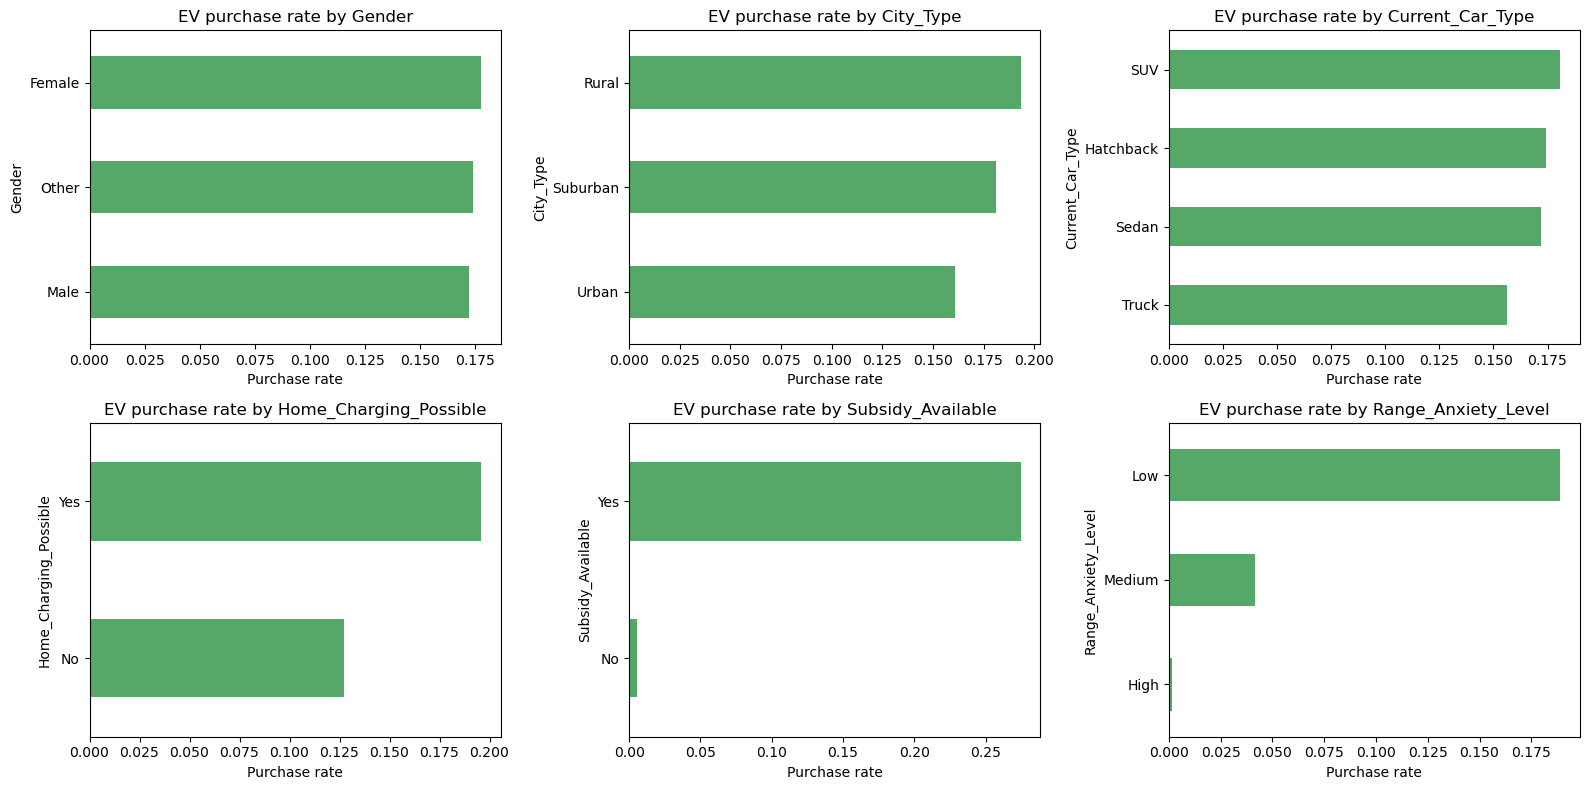

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, categorical_cols):
    rate = df.groupby(col)["Will_Buy_EV"].apply(lambda s: (s == "Yes").mean())
    rate.sort_values().plot(kind="barh", ax=ax, color="#55A868")
    ax.set_title(f"EV purchase rate by {col}")
    ax.set_xlabel("Purchase rate")
plt.tight_layout()
plt.show()


## 4. Feature engineering

engineered features, each with a hypothesis behind it,

| feature | hypothesis |
|---|---|
| `Total_Charging_Stations` | combined home+work charging access as a single signal |
| `Income_per_Car` | a household splitting income across more cars has less to spend on an EV premium |
| `Commute_to_Income_Ratio` | longer commutes relative to income may push toward (or away from) EV economics |
| `Range_Anxiety_Ordinal` | Low/Medium/High is ordinal so encoding them as one col |
| `Home_Charging_Flag`, `Subsidy_Flag` | Binary flags |
| `Subsidy_x_NoHomeCharging` | a subsidy should matter more to someone who *can't* already charge at home |
| `EnvConcern_x_ChargingAccess` |  environmental concern converts to a purchase more easily when charging is already convenient |


In [11]:
RANGE_ANXIETY_ORDER = {"Low": 0, "Medium": 1, "High": 2}

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Total_Charging_Stations"] = (
        df["Charging_Stations_Near_Home"] + df["Charging_Stations_Near_Work"]
    )
    df["Income_per_Car"] = df["Annual_Income_USD"] / (df["Number_of_Cars_Owned"] + 1)
    df["Commute_to_Income_Ratio"] = df["Daily_Commute_km"] / (df["Annual_Income_USD"] / 1000)
    df["Range_Anxiety_Ordinal"] = df["Range_Anxiety_Level"].map(RANGE_ANXIETY_ORDER)
    df["Home_Charging_Flag"] = (df["Home_Charging_Possible"] == "Yes").astype(int)
    df["Subsidy_Flag"] = (df["Subsidy_Available"] == "Yes").astype(int)
    df["Subsidy_x_NoHomeCharging"] = df["Subsidy_Flag"] * (1 - df["Home_Charging_Flag"])
    df["EnvConcern_x_ChargingAccess"] = (
        df["Environmental_Concern_Level"] * df["Total_Charging_Stations"]
    )
    return df

RAW_NUMERIC = numeric_cols
RAW_CATEGORICAL = categorical_cols

ENGINEERED_NUMERIC = RAW_NUMERIC + [
    "Total_Charging_Stations", "Income_per_Car", "Commute_to_Income_Ratio",
    "Range_Anxiety_Ordinal", "Home_Charging_Flag", "Subsidy_Flag",
    "Subsidy_x_NoHomeCharging", "EnvConcern_x_ChargingAccess",
]

ENGINEERED_CATEGORICAL = ["Gender", "City_Type", "Current_Car_Type"]

df_eng = engineer_features(df)
df_eng[ENGINEERED_NUMERIC + ENGINEERED_CATEGORICAL].head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Total_Charging_Stations,Income_per_Car,Commute_to_Income_Ratio,Range_Anxiety_Ordinal,Home_Charging_Flag,Subsidy_Flag,Subsidy_x_NoHomeCharging,EnvConcern_x_ChargingAccess,Gender,City_Type,Current_Car_Type
id,,,,,,,,,,,,,,,,,,
0,66,92887.0,23.4,2,3,7,1.0,10,30962.333333,0.251919,0,1,0,0,10.0,Male,Suburban,Sedan
1,38,30000.0,5.0,1,2,2,4.0,4,15000.000000,0.166667,0,1,0,0,16.0,Male,Rural,SUV
2,26,94389.0,36.8,1,8,15,5.0,23,47194.500000,0.389876,0,0,1,1,115.0,Female,Urban,Sedan
3,66,73580.0,23.7,2,6,9,3.0,15,24526.666667,0.322098,0,1,0,0,45.0,Male,Suburban,Hatchback
4,54,57898.0,50.8,1,2,3,3.0,5,28949.000000,0.877405,0,1,0,0,15.0,Male,Suburban,Hatchback


## 5. Train/test split

Stratified 80/20 split on the target to preserve the ~17.5% positive rate in both sets.  Built two parallel splits (raw vs. engineered feature frames) from the **same random_state**, and so the comparison in Section 7 is apples-to-apples.


In [12]:
y = (df["Will_Buy_EV"] == "Yes").astype(int)

df_raw = df[RAW_NUMERIC + RAW_CATEGORICAL]
df_eng_features = df_eng[ENGINEERED_NUMERIC + ENGINEERED_CATEGORICAL]

Xr_train, Xr_test, y_train, y_test = train_test_split(
    df_raw, y, test_size=0.2, random_state=42, stratify=y
)
Xe_train, Xe_test, _, _ = train_test_split(
    df_eng_features, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train rows: {len(Xr_train):,}  Test rows: {len(Xr_test):,}")
print(f"Positive rate train/test: {y_train.mean():.3f} / {y_test.mean():.3f}")


Train rows: 534,932  Test rows: 133,733
Positive rate train/test: 0.175 / 0.175


## 6. Preprocessing pipeline

One shared builder function for both models so the only thing that changes between experiments is (a) which feature set goes in and (b) whether the algorithm needs scaling (cause log reg needs it, but tree based models dont)


In [13]:
def build_preprocessor(numeric_cols, categorical_cols, scale: bool) -> ColumnTransformer:
    numeric_step = StandardScaler() if scale else "passthrough"
    prep = ColumnTransformer(
        transformers=[
            ("num", numeric_step, numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ]
    )
    prep.set_output(transform="pandas")
    return prep


## 7. Baseline vs. boosting: the 2x2 ablation

four models, same train/test split, same evaluation metrc:

1. logistic regression + raw features (the plain baseline)
2. logistic regression + engineered features
3. lightGBM + raw features
4. lightGBM + engineered features

Helps answer two separate questions in one table: **does the algorithm matter**, and **does the feature engineering matter**


In [14]:
def evaluate(name, pipe, X_train, y_train, X_test, y_test, plot_roc=True):
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    print(f"{name:35s}  ROC-AUC={auc:.4f}  PR-AUC={ap:.4f}")
    if plot_roc:
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
    return pipe, auc, ap

results = {}
plt.figure(figsize=(7, 7))


<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

LogReg + raw                         ROC-AUC=0.9380  PR-AUC=0.7399


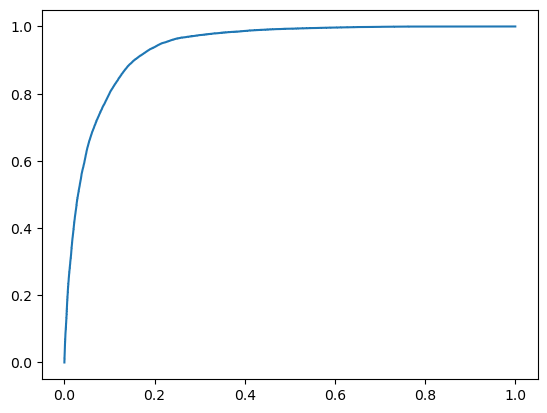

In [15]:
# 1. Logistic Regression + raw features (the plain baseline)
lr_raw = Pipeline([
    ("prep", build_preprocessor(RAW_NUMERIC, RAW_CATEGORICAL, scale=True)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
lr_raw, auc, ap = evaluate("LogReg + raw", lr_raw, Xr_train, y_train, Xr_test, y_test)
results["LogReg + raw features"] = (auc, ap)


LogReg + engineered                  ROC-AUC=0.9380  PR-AUC=0.7400


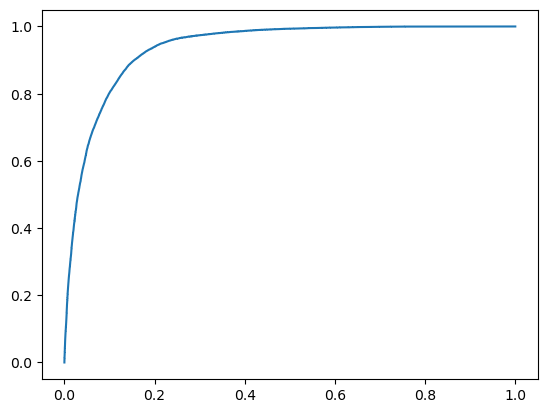

In [16]:
# 2. logisticc regression + engineered features
lr_eng = Pipeline([
    ("prep", build_preprocessor(ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL, scale=True)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
lr_eng, auc, ap = evaluate("LogReg + engineered", lr_eng, Xe_train, y_train, Xe_test, y_test)
results["LogReg + engineered features"] = (auc, ap)


In [17]:
# reweighting the classes
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for LightGBM (handles the 17.5% positive rate): {scale_pos_weight:.3f}")


scale_pos_weight for LightGBM (handles the 17.5% positive rate): 4.726


LightGBM + raw                       ROC-AUC=0.9414  PR-AUC=0.7549


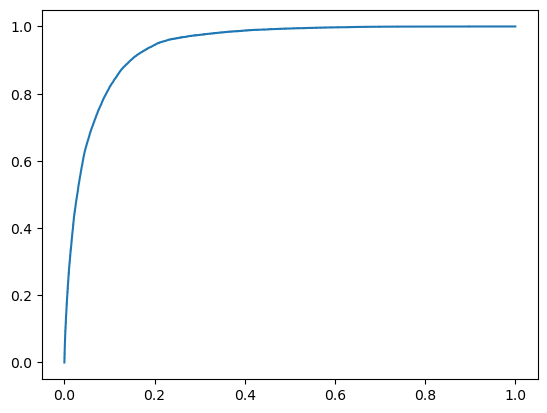

In [18]:
# 3. lightGBM + raw features
lgbm_raw = Pipeline([
    ("prep", build_preprocessor(RAW_NUMERIC, RAW_CATEGORICAL, scale=False)),
    ("clf", LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1,
    )),
])
lgbm_raw, auc, ap = evaluate("LightGBM + raw", lgbm_raw, Xr_train, y_train, Xr_test, y_test)
results["LightGBM + raw features"] = (auc, ap)


LightGBM + engineered                ROC-AUC=0.9414  PR-AUC=0.7544


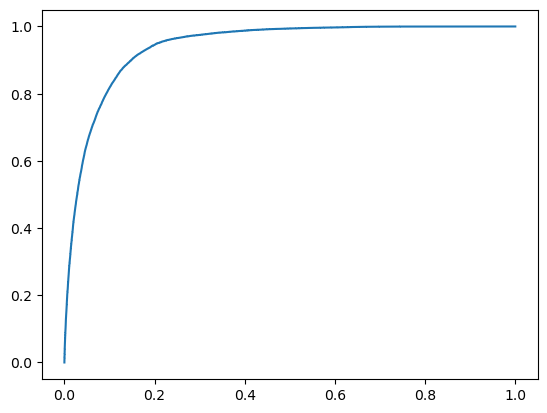

In [19]:
# 4. lightGBM + engineered features
lgbm_eng = Pipeline([
    ("prep", build_preprocessor(ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL, scale=False)),
    ("clf", LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1,
    )),
])
lgbm_eng, auc, ap = evaluate("LightGBM + engineered", lgbm_eng, Xe_train, y_train, Xe_test, y_test)
results["LightGBM + engineered features"] = (auc, ap)

### 7.1 Results table

Compare against the **live leaderboard context noted in Section 0**: top public scores clustered around 0.9465-0.9467 AUC. Anything in that neighborhood from a single untuned model, with no ensembling, is a strong result.


In [20]:
results_df = pd.DataFrame(results, index=["ROC-AUC", "PR-AUC"]).T
baseline_auc = results_df.loc["LogReg + raw features", "ROC-AUC"]
results_df["Delta vs. plain baseline"] = results_df["ROC-AUC"] - baseline_auc
results_df.round(4)

,ROC-AUC,PR-AUC,Delta vs. plain baseline
LogReg + raw features,0.9380,0.7399,0.0000
LogReg + engineered features,0.9380,0.7400,0.0001
LightGBM + raw features,0.9414,0.7549,0.0035
LightGBM + engineered features,0.9414,0.7544,0.0034


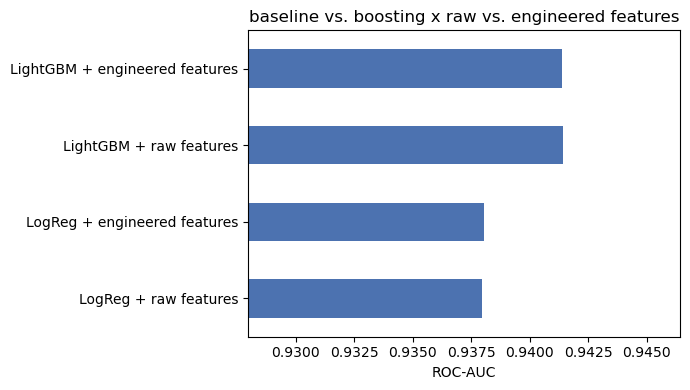

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df["ROC-AUC"].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlim(results_df["ROC-AUC"].min() - 0.01, results_df["ROC-AUC"].max() + 0.005)
ax.set_xlabel("ROC-AUC")
ax.set_title("baseline vs. boosting x raw vs. engineered features")
plt.tight_layout()
plt.show()

**What conclusions can we derive from this:**

Engineered features barely or not even moved the needle. This shows that the given features alone better represent the data, given its a synthetic one. Confirming this again with the feature importance of lightgbm

## 8. Feature importance (LightGBM + engineered features)

Wanted to know if any of the engiennered features did had a impact on the model performance or did the model ignore them in favor of the plain features they were built from?


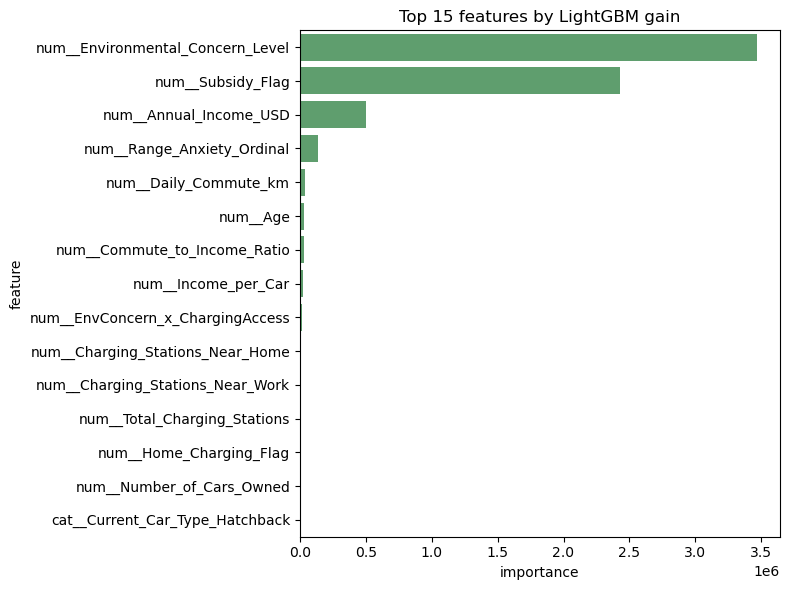

,feature,importance
6,num__Environmental_Concern_Level,3.468569e+06
12,num__Subsidy_Flag,2.430065e+06
1,num__Annual_Income_USD,4.998656e+05
10,num__Range_Anxiety_Ordinal,1.385257e+05
2,num__Daily_Commute_km,4.208458e+04
0,num__Age,3.389664e+04
9,num__Commute_to_Income_Ratio,2.806948e+04
8,num__Income_per_Car,2.412309e+04
14,num__EnvConcern_x_ChargingAccess,1.453385e+04
4,num__Charging_Stations_Near_Home,9.765413e+03


In [22]:
feature_names = lgbm_eng.named_steps["prep"].get_feature_names_out()
importances = lgbm_eng.named_steps["clf"].booster_.feature_importance(importance_type="gain")
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_df.head(15), y="feature", x="importance", ax=ax, color="#55A868")
ax.set_title("Top 15 features by LightGBM gain")
plt.tight_layout()
plt.show()

imp_df.head(15)


## 9. Classification report at the default 0.5 threshold

ROC-AUC and PR-AUC are threshold-independent, but it's worth also loking at a concrete confusion matrix / precision-recall at a real decision threshold, since some may be intereseted in other metrics, depending on their use case


              precision    recall  f1-score   support

          No       0.98      0.84      0.90    110377
         Yes       0.55      0.91      0.69     23356

    accuracy                           0.85    133733
   macro avg       0.76      0.88      0.79    133733
weighted avg       0.90      0.85      0.87    133733



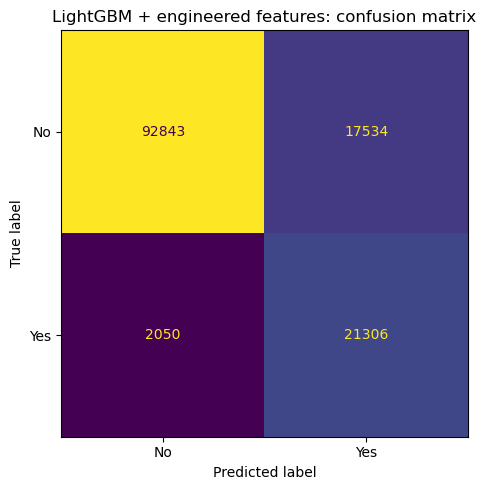

In [23]:
best_pipe = lgbm_eng
best_preds = best_pipe.predict(Xe_test)

print(classification_report(y_test, best_preds, target_names=["No", "Yes"]))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds, display_labels=["No", "Yes"], ax=ax, colorbar=False
)
ax.set_title("LightGBM + engineered features: confusion matrix")
plt.tight_layout()
plt.show()


## 10. Hyperparameter tuning (Bayesian optimization with Optuna)

Everything up to this point used hand-picked LightGBM settings (`n_estimators=400, max_depth=6, learning_rate=0.05`). And so I wnated to see if tuning lightgbm with engineered features can have a performance boost


In [24]:
import optuna
from sklearn.model_selection import StratifiedKFold

N_TRIALS = 50
N_FOLDS = 5

def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_aucs = []
    for train_idx, val_idx in skf.split(Xe_train, y_train):
        X_tr, X_val = Xe_train.iloc[train_idx], Xe_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe = Pipeline([
            ("prep", build_preprocessor(ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL, scale=False)),
            ("clf", LGBMClassifier(
                **params, scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1,
            )),
        ])
        pipe.fit(X_tr, y_tr)
        proba = pipe.predict_proba(X_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, proba))

    return float(np.mean(fold_aucs))

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best mean 5-fold CV AUC:", study.best_value)
print("Best params:", study.best_params)


[I 2026-09-19 22:18:55,304] A new study created in memory with name: no-name-b72dd618-df8b-43db-a07a-3f6744e442f4


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-19 22:19:26,107] Trial 0 finished with value: 0.9389243409775088 and parameters: {'num_leaves': 105, 'max_depth': 12, 'learning_rate': 0.08960785365368121, 'n_estimators': 559, 'min_child_samples': 19, 'feature_fraction': 0.5779972601681014, 'bagging_fraction': 0.5290418060840998, 'bagging_freq': 7, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682}. Best is trial 0 with value: 0.9389243409775088.
[I 2026-09-19 22:19:39,981] Trial 1 finished with value: 0.941223462814946 and parameters: {'num_leaves': 19, 'max_depth': 12, 'learning_rate': 0.12106896936002161, 'n_estimators': 327, 'min_child_samples': 22, 'feature_fraction': 0.5917022549267169, 'bagging_fraction': 0.6521211214797689, 'bagging_freq': 4, 'reg_alpha': 7.71800699380605e-05, 'reg_lambda': 4.17890272377219e-06}. Best is trial 1 with value: 0.941223462814946.
[I 2026-09-19 22:19:58,125] Trial 2 finished with value: 0.9406953961603822 and parameters: {'num_leaves': 162, 'max_depth': 4, 'learning_r

### 10.1 Optimization diagnostics

C:\Users\thill\AppData\Local\Temp\ipykernel_25824\958145405.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


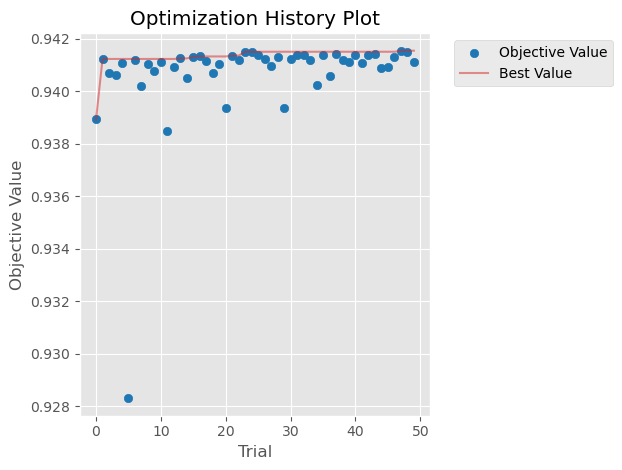

C:\Users\thill\AppData\Local\Temp\ipykernel_25824\958145405.py:7: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


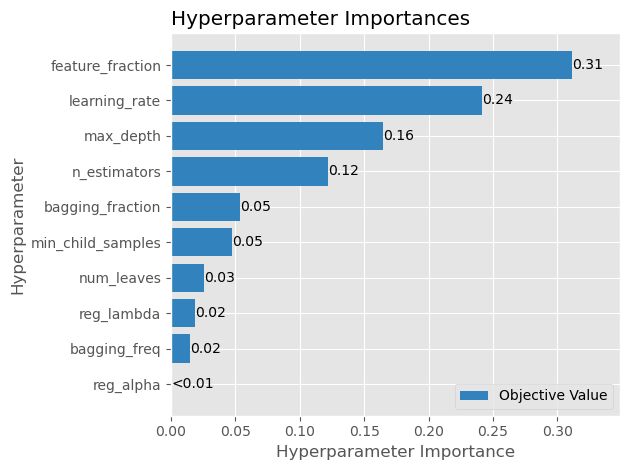

In [25]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

plot_optimization_history(study)
plt.tight_layout()
plt.show()

plot_param_importances(study)
plt.tight_layout()
plt.show()


### 10.2 Refit with the tuned parameters and compare

Refit on the full training split with the best trial's parameters, then evaluate on the **same held-out test set** used for every other model in this notebook (Section 7), so the comparison is apples-to-apples.


In [37]:
lgbm_tuned = Pipeline([
    ("prep", build_preprocessor(ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL, scale=False)),
    ("clf", LGBMClassifier(
        **study.best_params, scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1,
    )),
])
lgbm_tuned, tuned_auc, tuned_ap = evaluate(
    "LightGBM + engineered + tuned", lgbm_tuned, Xe_train, y_train, Xe_test, y_test, plot_roc=False
)

untuned_auc = results["LightGBM + engineered features"][0]
print(f"Untuned LightGBM + engineered features:  AUC={untuned_auc:.4f}")
print(f"Tuned   LightGBM + engineered features:  AUC={tuned_auc:.4f}")
print(f"Improvement from tuning:                 {tuned_auc - untuned_auc:+.4f}")

LightGBM + engineered + tuned        ROC-AUC=0.9414  PR-AUC=0.7545
Untuned LightGBM + engineered features:  AUC=0.9414
Tuned   LightGBM + engineered features:  AUC=0.9414
Improvement from tuning:                 -0.0000


## 11. XGBoost: Bayesian tuning and comparison

Same approach as Section 10 but with XGBoost instead of lightgbm


In [27]:
from xgboost import XGBClassifier

def objective_xgb(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_aucs = []
    for train_idx, val_idx in skf.split(Xe_train, y_train):
        X_tr, X_val = Xe_train.iloc[train_idx], Xe_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe = Pipeline([
            ("prep", build_preprocessor(ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL, scale=False)),
            ("clf", XGBClassifier(
                **params, scale_pos_weight=scale_pos_weight, random_state=42,
                tree_method="hist", eval_metric="auc", n_jobs=-1,
            )),
        ])
        pipe.fit(X_tr, y_tr)
        proba = pipe.predict_proba(X_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, proba))

    return float(np.mean(fold_aucs))

study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

print("Best mean 5-fold CV AUC (XGBoost):", study_xgb.best_value)
print("Best params:", study_xgb.best_params)


[I 2026-09-19 22:36:24,214] A new study created in memory with name: no-name-ae747d7c-052f-4a7c-b75b-8fa22df38aeb


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-19 22:37:01,345] Trial 0 finished with value: 0.9378545974743631 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 639, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 3.3323645788192616e-08, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.9378545974743631.
[I 2026-09-19 22:38:04,188] Trial 1 finished with value: 0.9410834206903814 and parameters: {'max_depth': 8, 'learning_rate': 0.010725209743171996, 'n_estimators': 782, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 4.4734294104626844e-07, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 1 with value: 0.9410834206903814.
[I 2026-09-19 22:38:40,264] Trial 2 finished with value: 0.9413335479104725 and parameters: {'max_depth': 6, 'learning_rate': 0.02692655251486473, 'n_estimators': 567, 

### 11.1 Optimization diagnostics

C:\Users\thill\AppData\Local\Temp\ipykernel_25824\3573681561.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_xgb)


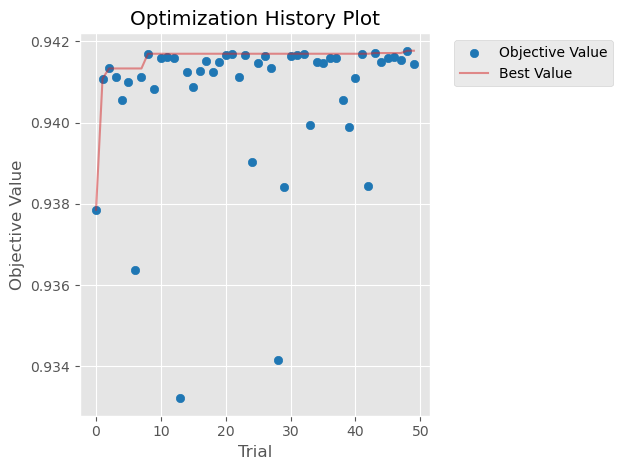

C:\Users\thill\AppData\Local\Temp\ipykernel_25824\3573681561.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_xgb)


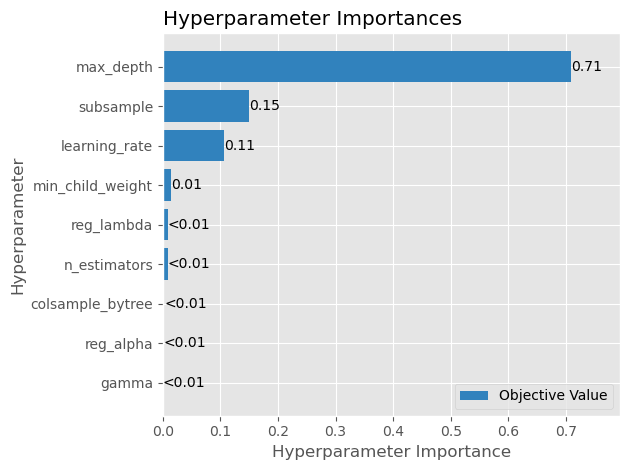

In [28]:
plot_optimization_history(study_xgb)
plt.tight_layout()
plt.show()

plot_param_importances(study_xgb)
plt.tight_layout()
plt.show()


### 11.2 Refit with the tuned parameters


In [29]:
xgb_tuned = Pipeline([
    ("prep", build_preprocessor(ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL, scale=False)),
    ("clf", XGBClassifier(
        **study_xgb.best_params, scale_pos_weight=scale_pos_weight, random_state=42,
        tree_method="hist", eval_metric="auc", n_jobs=-1,
    )),
])
xgb_tuned, xgb_auc, xgb_ap = evaluate(
    "XGBoost + engineered + tuned", xgb_tuned, Xe_train, y_train, Xe_test, y_test, plot_roc=False
)

print(f"Untuned LightGBM AUC: {untuned_auc:.4f}")
print(f"Tuned   LightGBM AUC: {tuned_auc:.4f}")
print(f"Tuned   XGBoost  AUC: {xgb_auc:.4f}")


XGBoost + engineered + tuned         ROC-AUC=0.9416  PR-AUC=0.7567
Untuned LightGBM AUC: 0.9414
Tuned   LightGBM AUC: 0.9414
Tuned   XGBoost  AUC: 0.9416


## 12. Stacking ensemble: LightGBM + XGBoost + Random Forest + a small ANN

Four base models chosen for **diversity of inductive bias**, not just "more models", which incldue:

- LightGBM (tuned, Section 10)
- XGBoost (tuned, Section 11)
- Random Forest
- Small ANN (`MLPClassifier`)


**How the stacking is built, and why it's built this way:**
1. For each of the 4 base models, generated **out-of-fold (OOF) predictions** on `Xe_train` via 5-fold CV - every training row gets a prediction from a model that never saw that row during training. This is what the meta-model trains on; using in-sample predictions instead would leak and make the meta-model overfit.
2. For the test set, each base model is trained once per fold, and its 5 fold-models' test predictions are **averaged**
3. The meta-model is **plain Logistic Regression**, deliberately linear rather than another boosted tree.


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

N_STACK_FOLDS = 5

base_model_builders = {
    "lgbm": lambda: LGBMClassifier(
        **study.best_params, scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1,
    ),
    "xgb": lambda: XGBClassifier(
        **study_xgb.best_params, scale_pos_weight=scale_pos_weight, random_state=42,
        tree_method="hist", eval_metric="auc", n_jobs=-1,
    ),
    "rf": lambda: RandomForestClassifier(
        n_estimators=500, max_depth=12, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1,
    ),
    "ann": lambda: MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu", alpha=1e-4,
        max_iter=300, early_stopping=True, random_state=42,
    ),
}
# the ANN needs scaled numeric inputs (like Logistic Regression did); the
# tree-based models don't
NEEDS_SCALING = {"lgbm": False, "xgb": False, "rf": False, "ann": True}

skf_stack = StratifiedKFold(n_splits=N_STACK_FOLDS, shuffle=True, random_state=42)

oof_preds = {name: np.zeros(len(Xe_train)) for name in base_model_builders}
test_fold_preds = {name: np.zeros((len(Xe_test), N_STACK_FOLDS)) for name in base_model_builders}

for fold, (tr_idx, val_idx) in enumerate(skf_stack.split(Xe_train, y_train)):
    X_tr, X_val = Xe_train.iloc[tr_idx], Xe_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    for name, builder in base_model_builders.items():
        pipe = Pipeline([
            ("prep", build_preprocessor(ENGINEERED_NUMERIC, ENGINEERED_CATEGORICAL, scale=NEEDS_SCALING[name])),
            ("clf", builder()),
        ])
        pipe.fit(X_tr, y_tr)
        oof_preds[name][val_idx] = pipe.predict_proba(X_val)[:, 1]
        test_fold_preds[name][:, fold] = pipe.predict_proba(Xe_test)[:, 1]

    print(f"Fold {fold + 1}/{N_STACK_FOLDS} done")

test_preds = {name: test_fold_preds[name].mean(axis=1) for name in base_model_builders}

print()
print("Individual base model performance:")
for name in base_model_builders:
    oof_auc = roc_auc_score(y_train, oof_preds[name])
    test_auc = roc_auc_score(y_test, test_preds[name])
    print(f"  {name:5s}  OOF AUC={oof_auc:.4f}   Test AUC={test_auc:.4f}")


Fold 1/5 done
Fold 2/5 done
Fold 3/5 done
Fold 4/5 done
Fold 5/5 done

Individual base model performance:
  lgbm   OOF AUC=0.9415   Test AUC=0.9415
  xgb    OOF AUC=0.9418   Test AUC=0.9417
  rf     OOF AUC=0.9390   Test AUC=0.9390
  ann    OOF AUC=0.9380   Test AUC=0.9385


### 12.1 Simple average vs. stacked (logistic regression meta-model)

Compare the cheap baseline (just average all four base models' probabilities) against actually learning combination weights.


In [31]:
# simple average, cheap baseline for combining models
simple_avg_test = np.mean([test_preds[name] for name in base_model_builders], axis=0)
simple_avg_auc = roc_auc_score(y_test, simple_avg_test)

# stacking with a meta learnerr
meta_X_train = np.column_stack([oof_preds[name] for name in base_model_builders])
meta_X_test = np.column_stack([test_preds[name] for name in base_model_builders])

meta_model = LogisticRegression()
meta_model.fit(meta_X_train, y_train)
stack_test_proba = meta_model.predict_proba(meta_X_test)[:, 1]
stack_auc = roc_auc_score(y_test, stack_test_proba)

print("Meta-model learned weight per base model:")
for name, coef in zip(base_model_builders.keys(), meta_model.coef_[0]):
    print(f"  {name:5s}  weight={coef:+.3f}")

print()
print(f"Tuned LightGBM alone:      AUC={tuned_auc:.4f}")
print(f"Tuned XGBoost alone:       AUC={xgb_auc:.4f}")
print(f"Simple average (4 models): AUC={simple_avg_auc:.4f}")
print(f"Stacked ensemble (4 models): AUC={stack_auc:.4f}")


Meta-model learned weight per base model:
  lgbm   weight=+2.769
  xgb    weight=+4.057
  rf     weight=-1.541
  ann    weight=+1.060

Tuned LightGBM alone:      AUC=0.9414
Tuned XGBoost alone:       AUC=0.9416
Simple average (4 models): AUC=0.9408
Stacked ensemble (4 models): AUC=0.9415


## 13. All results, side by side

Every model and ablation from this notebook, gathered into one table for combined results viewing


In [32]:
all_results = {}

# 2x2 ablation (Section 7): logReg/LightGBM x raw/engineered features
for name, (auc, ap) in results.items():
    all_results[name] = {"ROC-AUC": auc, "PR-AUC": ap, "Category": "2x2 ablation"}

# tuned single models (Sections 10-11)
all_results["LightGBM + engineered + tuned"] = {
    "ROC-AUC": tuned_auc, "PR-AUC": tuned_ap, "Category": "Tuned single model",
}
all_results["XGBoost + engineered + tuned"] = {
    "ROC-AUC": xgb_auc, "PR-AUC": xgb_ap, "Category": "Tuned single model",
}

# the 4 base models used inside the stacking ensemble (Section 12), scored on the test set
for name in base_model_builders:
    all_results[f"Stacking base: {name}"] = {
        "ROC-AUC": roc_auc_score(y_test, test_preds[name]),
        "PR-AUC": average_precision_score(y_test, test_preds[name]),
        "Category": "Stacking base model",
    }

# the two ways of combining those 4 base models (Section 12.1)
all_results["Simple average (4 models)"] = {
    "ROC-AUC": simple_avg_auc,
    "PR-AUC": average_precision_score(y_test, simple_avg_test),
    "Category": "Ensemble",
}
all_results["Stacked ensemble (4 models)"] = {
    "ROC-AUC": stack_auc,
    "PR-AUC": average_precision_score(y_test, stack_test_proba),
    "Category": "Ensemble",
}

summary_df = pd.DataFrame(all_results).T
summary_df[["ROC-AUC", "PR-AUC"]] = summary_df[["ROC-AUC", "PR-AUC"]].astype(float)
summary_df = summary_df.sort_values("ROC-AUC", ascending=False)
summary_df.round(4)


,ROC-AUC,PR-AUC,Category
Stacking base: xgb,0.9417,0.7565,Stacking base model
XGBoost + engineered + tuned,0.9416,0.7567,Tuned single model
Stacked ensemble (4 models),0.9415,0.7547,Ensemble
Stacking base: lgbm,0.9415,0.7551,Stacking base model
LightGBM + raw features,0.9414,0.7549,2x2 ablation
LightGBM + engineered features,0.9414,0.7544,2x2 ablation
LightGBM + engineered + tuned,0.9414,0.7545,Tuned single model
Simple average (4 models),0.9408,0.7499,Ensemble
Stacking base: rf,0.9390,0.7424,Stacking base model
Stacking base: ann,0.9385,0.7407,Stacking base model


### 13.1 Everything, ranked in one chart

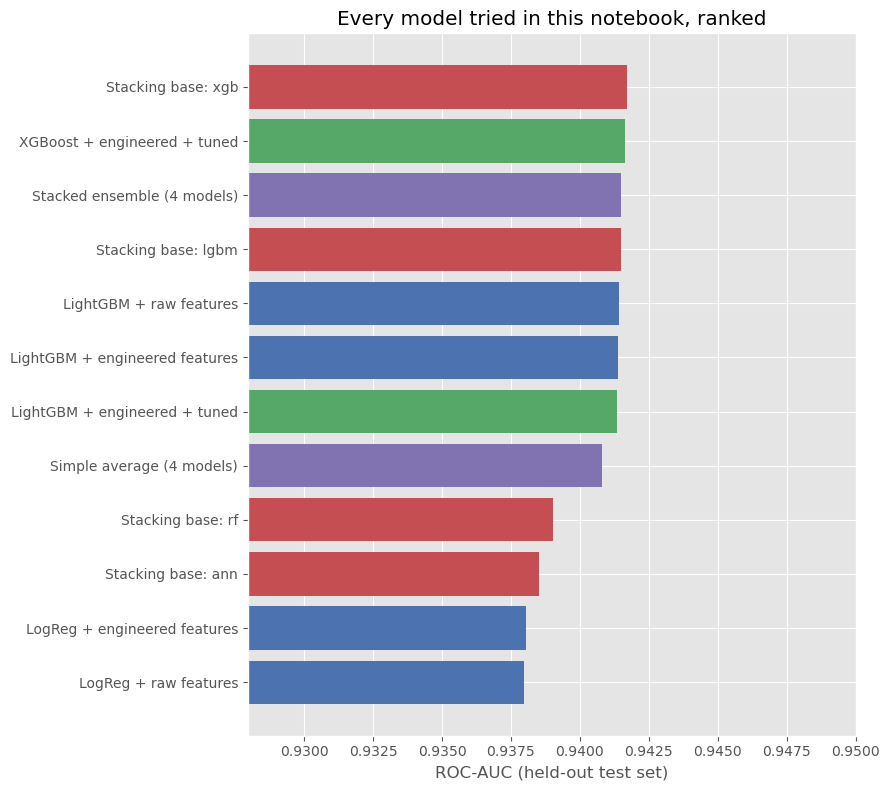

In [38]:
category_colors = {
    "2x2 ablation": "#4C72B0",
    "Tuned single model": "#55A868",
    "Stacking base model": "#C44E52",
    "Ensemble": "#8172B2",
}
bar_colors = summary_df["Category"].map(category_colors)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(summary_df.index[::-1], summary_df["ROC-AUC"][::-1], color=bar_colors[::-1])
ax.set_xlim(summary_df["ROC-AUC"].min() - 0.01, 0.95)
ax.set_xlabel("ROC-AUC (held-out test set)")
ax.set_title("Every model tried in this notebook, ranked")
plt.tight_layout()
plt.show()


## Conclusion

- Boosting (LightGBM/XGBoost, 0.9414–0.9417) clearly beats Logistic Regression (0.9380), Random Forest (0.9390), and the ANN (0.9385) but boosting variants are now interchangeable with each other
- The ensemble (0.9408–0.9415) never beat the single best model (tuned XGBoost, 0.9417). Random Forest and the ANN were too weak to add useful diversity in the ensembling and they might have dragged the average down
- One lesson for myself: ensembling only pays off when our base models are comparably strong, diversity alsone from a weak model doesn't offset the accuracy it loses you